In [1]:
# widen jupyter notebook window
from IPython.display import display, HTML
display(HTML("<style>.container {width:95% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

In [2]:
import gc 
import multiprocessing as mp
import copy
import functools
from pathlib import Path
import math

import torch
import torchaudio
import numpy as np
import scipy.signal
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pandas as pd

In [3]:
%load_ext autoreload
%autoreload 2
import bnpm

In [4]:
%load_ext autoreload
%autoreload 2
import roicat

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# multiday day 0 animals:
# 0322R: 20230425

# single day day 0 animals:
# 0403L: 20230703
# 0403R: 20230703

In [6]:
# test = bnpm.file_helpers.pickle_load('/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0322R/analysis/fig4_crossDecomposition/BMI_factor_1_factor_only/results_preprocessing.pkl')
# test['dates']

In [7]:
# %matplotlib notebook

In [51]:
mouse = 'mouse_0403R'
date_day0 = '20230703'

In [9]:
# session_type = 'multi_day'
session_type = 'single_day'

In [10]:
find_date = lambda p: bnpm.path_helpers.find_date_in_path(p, regex_date_formats=['\\d{4}\\d{2}\\d{2}'])

In [11]:
# paths_FR = bnpm.path_helpers.find_paths(
#     dir_outer=f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/positions_and_dFoF_aligned_idxSI4x/',
#     # dir_outer=f'/media/rich/OS/data/tmp/positions_and_dFoF_aligned_idxSI4x/{mouse}/',
#     reMatch=f'val_points__idx_SI4x\.npy',
#     find_files=True,
#     depth=4,
#     verbose=False,
# )
# paths_FR = {find_date(p): p for p in paths_FR}

# # paths_FR = {d: p for d, p in paths_FR.items() if d in test['dates']}

# display(paths_FR)

In [12]:
# paths_neural = bnpm.path_helpers.find_paths(
#     dir_outer=f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/positions_and_dFoF_aligned_idxSI4x/',
#     reMatch=f'val_dFoF__idx_SI4x\.npy',
#     find_files=True,
#     depth=4,
#     verbose=False,
# )
# paths_neural = {find_date(p): p for p in paths_neural}
# display(paths_neural)

In [13]:
paths_neural = bnpm.path_helpers.find_paths(
    dir_outer=f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/spks/',
    reMatch=f'spks\.npy',
    find_files=True,
    depth=4,
    verbose=False,
)
paths_neural = {find_date(p): p for p in paths_neural}
display(paths_neural)

{'20230702': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/spks/20230702/spks.npy',
 '20230703': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/spks/20230703/spks.npy',
 '20230706': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/spks/20230706/spks.npy',
 '20230707': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/spks/20230707/spks.npy',
 '20230708': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/spks/20230708/spks.npy',
 '20230709': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/spks/20230709/spks.npy'}

In [14]:
paths_tqm = bnpm.path_helpers.find_paths(
    dir_outer=f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/dFoF_and_tqm/',
    reMatch=f'iscell_tqm\.npy',
    find_files=True,
    depth=4,
    verbose=False,
)
paths_tqm = {find_date(p): p for p in paths_tqm}
display(paths_tqm)

{'20230702': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/dFoF_and_tqm/20230702/jobNum_0/iscell_tqm.npy',
 '20230703': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/dFoF_and_tqm/20230703/jobNum_0/iscell_tqm.npy',
 '20230706': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/dFoF_and_tqm/20230706/jobNum_0/iscell_tqm.npy',
 '20230707': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/dFoF_and_tqm/20230707/jobNum_0/iscell_tqm.npy',
 '20230708': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/dFoF_and_tqm/20230708/jobNum_0/iscell_tqm.npy',
 '20230709': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/dFoF_and_tqm/20230709/jobNum_0/iscell_tqm.npy'}

In [15]:
paths_ws = bnpm.path_helpers.find_paths(
    dir_outer=f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/',
    # dir_outer=f'/media/rich/OS/data/tmp/positions_and_dFoF_aligned_idxSI4x/{mouse}/',    
    reMatch='ws_idxSI.pkl',
    # reMatch_in_path='positions_and_dFoF_aligned_idxSI4x',
    depth=6,
    verbose=False,
)
paths_ws = {find_date(p): p for p in paths_ws}
display(paths_ws)

{'20230702': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/ws_and_tca__idx_SI/20230702/ws_idxSI.pkl',
 '20230703': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/spks_aligned_idxSI4x/20230703/ws_idxSI.pkl',
 '20230706': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/ws_and_tca__idx_SI/20230706/ws_idxSI.pkl',
 '20230707': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/ws_and_tca__idx_SI/20230707/ws_idxSI.pkl',
 '20230708': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/ws_and_tca__idx_SI/20230708/ws_idxSI.pkl',
 '20230709': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/ws_and_tca__idx_SI/20230709/ws_idxSI.pkl'}

In [ ]:
paths_loggers = bnpm.path_helpers.find_paths(
    # dir_outer=f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/',
    dir_outer=f'/media/rich/bigHDD/logger_alignment_data/{mouse}/',
    # reMatch=f'logger',
    reMatch=f'logger_aligned\.mat',
    depth=6,
    verbose=False,
)
paths_loggers = {find_date(p): p for p in paths_loggers}
display(paths_loggers)

{'20230702': '/media/rich/bigHDD/logger_alignment_data/mouse_0403R/20230702/analysis_data/logger_aligned.mat',
 '20230703': '/media/rich/bigHDD/logger_alignment_data/mouse_0403R/20230703/analysis_data/logger_aligned.mat',
 '20230706': '/media/rich/bigHDD/logger_alignment_data/mouse_0403R/20230706/analysis_data/logger_aligned.mat',
 '20230707': '/media/rich/bigHDD/logger_alignment_data/mouse_0403R/20230707/analysis_data/logger_aligned.mat',
 '20230708': '/media/rich/bigHDD/logger_alignment_data/mouse_0403R/20230708/analysis_data/logger_aligned.mat',
 '20230709': '/media/rich/bigHDD/logger_alignment_data/mouse_0403R/20230709/analysis_data/logger_aligned.mat'}

In [17]:
paths_expParams = bnpm.path_helpers.find_paths(
    dir_outer=f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/',
    # dir_outer=f'/media/rich/bigHDD/logger_alignment_data/{mouse}/',
    # reMatch=f'logger',
    reMatch=f'expParams\.mat',
    depth=6,
    verbose=False,
)
paths_expParams = {find_date(p): p for p in paths_expParams}
display(paths_expParams)

{'20230702': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/loggers/20230702/expParams.mat',
 '20230703': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/loggers/20230703/expParams.mat',
 '20230706': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/loggers/20230706/expParams.mat',
 '20230707': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/loggers/20230707/expParams.mat',
 '20230708': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/loggers/20230708/expParams.mat',
 '20230709': '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403R/loggers/20230709/expParams.mat'}

In [18]:
path_roicatClassification = f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/{mouse}.ROICaT.classification_drawn.results.pkl'
path_roicatTracking       = f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/stat_and_ops.ROICaT.tracking.results.pkl'
# path_roicatTracking       = f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/{mouse}.ROICaT.tracking.results.pkl'


In [19]:
roicatClassification = bnpm.file_helpers.pickle_load(path_roicatClassification)

iscell_roicatClassification = {find_date(p): roicatClassification['preds'][ii].astype(np.bool_) for ii, p in enumerate(roicatClassification['input_data'])}


roicatTracking = bnpm.file_helpers.pickle_load(path_roicatTracking)

labels_bySession = {find_date(p): roicatTracking['clusters']['labels_bySession'][ii] for ii, p in enumerate(roicatTracking['input_data']['paths_stat'])}

sampleSilhouette_bySession = roicat.util.labels_to_labelsBySession(roicatTracking['quality_metrics']['sample_silhouette'], n_roi_bySession=[len(l) for l in roicatTracking['clusters']['labels_bySession']])
# sampleSilhouette_bySession = roicat.util.labels_to_labelsBySession(roicatTracking["clusters"]['quality_metrics']['sample_silhouette'], n_roi_bySession=[len(l) for l in roicatTracking['clusters']['labels_bySession']])
sampleSilhouette_bySession = {d: s for d, s in zip(labels_bySession.keys(), sampleSilhouette_bySession)}

In [20]:
date_sets = [set(p.keys()) for p in [
    # paths_FR, 
    paths_neural, 
    paths_tqm, 
    iscell_roicatClassification, 
    labels_bySession, 
    paths_ws, 
    paths_loggers,
    paths_expParams,
]]

In [21]:
dates = sorted(list(set.intersection(*date_sets)))

display(*date_sets)

dates = dates[:]

display(dates)

{'20230702', '20230703', '20230706', '20230707', '20230708', '20230709'}

{'20230702', '20230703', '20230706', '20230707', '20230708', '20230709'}

{'20230702', '20230703', '20230706', '20230707', '20230708', '20230709'}

{'20230702', '20230703', '20230706', '20230707', '20230708', '20230709'}

{'20230702', '20230703', '20230706', '20230707', '20230708', '20230709'}

{'20230702', '20230703', '20230706', '20230707', '20230708', '20230709'}

{'20230702', '20230703', '20230706', '20230707', '20230708', '20230709'}

['20230702', '20230703', '20230706', '20230707', '20230708', '20230709']

In [22]:
dates

['20230702', '20230703', '20230706', '20230707', '20230708', '20230709']

In [23]:
# dates = dates[0:21]

In [24]:
# dates = [
#     '20230703',
#     '20230705',
#     '20230706',
#     '20230707',
#     '20230708',
#     '20230709',
#     '20230710',
#     '20230711',
#     '20230712',
# ]

In [25]:
data_ws = {date: bnpm.file_helpers.pickle_load(paths_ws[date]) for date in dates}

In [26]:
def load_logger_data(path):
    out = bnpm.file_helpers.matlab_load(path)
    if 'loggers' in out:
        out = out['logger']
    elif 'logger_aligned' in out:
        out = out['logger_aligned']
    else:
        print(out.keys())
        raise ValueError(f'No logger data found in {path}')
    
    return out

In [27]:
loggers = {date: load_logger_data(paths_loggers[date]) for date in dates}

In [28]:
expParams = {date: bnpm.file_helpers.matlab_load(paths_expParams[date])['expParams'] for date in dates}

In [29]:
def load_data_FR(path):
    data_positions = np.load(path, mmap_mode='r')
    data_positions = data_positions.transpose(0,2,1).reshape(data_positions.shape[0], -1).astype(np.float32)
    return data_positions

def load_data_neural(path):
    # return np.load(path, mmap_mode='r').astype(np.float32)
    return np.load(path, mmap_mode='r')

def load_data_iscellTQM(path):
    return np.load(path).astype(np.bool_)

In [30]:
data_neural = {date: load_data_neural(paths_neural[date]) for date in tqdm(dates)}

iscells_tqm = {date: load_data_iscellTQM(paths_tqm[date]) for date in tqdm(dates)}

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

In [31]:
iscell_roicatClassification = {date: iscell_roicatClassification[date] for date in dates}
labels_bySession = {date: labels_bySession[date] for date in dates}
sampleSilhouette_bySession = {d: sampleSilhouette_bySession[d] for d in dates}

In [32]:
labels_bySession_modified = copy.deepcopy(labels_bySession)
labels_bySession_modified = roicat.util.mask_UCIDs_with_iscell(list(labels_bySession_modified.values()), list(iscell_roicatClassification.values()))
labels_bySession_modified = {d: s for d, s in zip(labels_bySession.keys(), labels_bySession_modified)}

In [33]:
roicatTracking['clusters'].keys()

dict_keys(['labels', 'labels_bySession', 'labels_bool', 'labels_bool_bySession', 'labels_dict'])

In [34]:
thresh_sampleSilhouette = 0.0
labels_bySession_modified = roicat.util.mask_UCIDs_with_iscell(list(labels_bySession_modified.values()), [s > thresh_sampleSilhouette for s in list(sampleSilhouette_bySession.values())])
labels_bySession_modified = {d: s for d, s in zip(labels_bySession.keys(), labels_bySession_modified)}

thresh_clusterSilhouette = -0.2
labels_bySession_modified = roicat.util.mask_UCIDs_by_label(list(labels_bySession_modified.values()), roicatTracking['quality_metrics']['cluster_labels_unique'][roicatTracking['quality_metrics']['cluster_silhouette'] > thresh_clusterSilhouette])
# labels_bySession_modified = roicat.util.mask_UCIDs_by_label(list(labels_bySession_modified.values()), np.array(roicatTracking['clusters']['quality_metrics']['cluster_labels_unique'])[np.array(roicatTracking['clusters']['quality_metrics']['cluster_silhouette']) > thresh_clusterSilhouette])
labels_bySession_modified = {d: t for d, t in zip(labels_bySession.keys(), labels_bySession_modified)}

In [35]:
labels_bySession_modified = roicat.util.discard_UCIDs_with_fewer_matches(list(labels_bySession_modified.values()), n_sesh_thresh='all')
labels_bySession_modified = {d: t for d, t in zip(labels_bySession.keys(), labels_bySession_modified)}

INFO: 28.86% of UCIDs that appear in at least 6 sessions.


In [36]:
labels_bySession_modified = roicat.util.squeeze_UCID_labels(list(labels_bySession_modified.values()))
labels_bySession_modified = {d: t for d, t in zip(labels_bySession.keys(), labels_bySession_modified)}

In [37]:
labels_bySession_modified.__len__()

6

In [38]:
labels = labels_bySession_modified

In [39]:
labels

{'20230702': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  -1,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  -1,
  23,
  24,
  -1,
  25,
  26,
  27,
  28,
  29,
  -1,
  30,
  31,
  32,
  -1,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  -1,
  43,
  44,
  45,
  -1,
  46,
  -1,
  47,
  -1,
  48,
  49,
  50,
  -1,
  -1,
  51,
  52,
  53,
  54,
  -1,
  -1,
  55,
  56,
  -1,
  -1,
  -1,
  -1,
  57,
  58,
  59,
  60,
  -1,
  61,
  -1,
  62,
  63,
  64,
  65,
  66,
  67,
  -1,
  68,
  69,
  70,
  -1,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  -1,
  78,
  79,
  80,
  81,
  -1,
  82,
  -1,
  -1,
  83,
  -1,
  84,
  85,
  86,
  -1,
  87,
  -1,
  88,
  -1,
  89,
  90,
  -1,
  -1,
  91,
  92,
  93,
  94,
  95,
  -1,
  96,
  -1,
  97,
  98,
  99,
  -1,
  -1,
  100,
  101,
  102,
  -1,
  -1,
  -1,
  103,
  104,
  105,
  106,
  107,
  108,
  -1,
  -1,
  -1,
  109,
  110,
  -1,
  -1,
  -1,
  -1,
  111,
  112,
  113,
  114,
  115,
  -1,
  -1,
  11

In [40]:
max_ucid = np.max([np.array(l).max() for l in labels.values()])
ucids_inverse = {date: roicat.util.invert_ucids(l, max_ucid=max_ucid) for date, l in labels.items()}

In [41]:
## the following two cells are from the coherence_decomp_trials_factors_remixDecoderWeights_singleDay.py file

In [42]:
decoderDefinition = np.load(f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/day0_analysis/decoder_definition.pkl', allow_pickle=True)

In [86]:
if session_type == 'single_day':
    path_weights_decoder = f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/day0_analysis/weights_day0.npy'
    # path_iscellClassifierMatchingTQM = f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/day0_analysis/iscell_classifier_matching_tqm.pkl'
    path_iscell = f"/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/day0_analysis/iscell_day0.npy"
    # idx_iscellClassifierMatchingTQM_day0 = 1
    # date_day0 = '20230703'

    weights = np.load(path_weights_decoder, allow_pickle=True)[()]
    iscell_day0 = np.load(path_iscell)
    weights_day0 = weights['factors'].T

    weights_day0_idxDay0 = np.zeros(shape=(iscell_day0.shape[0], weights_day0.shape[1]), dtype=weights_day0.dtype) * np.nan
    weights_day0_idxDay0[iscell_day0] = weights_day0  ## reforming the original day 0 indices

In [87]:
if session_type == 'multi_day':
    path_weights_decoder = f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/day0_analysis/weights_day0.npy'
    path_iscellClassifierMatchingTQM = f'/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/day0_analysis/iscell_classifier_matching_tqm.pkl'
    # path_iscell = f"/media/rich/bigSSD/analysis_data/face_rhythm/{mouse}/day0_analysis/iscell_day0.npy"
    # idx_iscellClassifierMatchingTQM_day0 = 1
    # date_day0 = '20230703'

    weights = np.load(path_weights_decoder, allow_pickle=True)[()]
    # iscell_classifier = np.load(path_iscell)
    iscell_classifier_matching_tqm = bnpm.file_helpers.pickle_load(path_iscellClassifierMatchingTQM)
    # ucids_day0_inverse = roicat.util.invert_ucids(roicat.util.squeeze_UCID_labels(iscell_classifier_matching_tqm['UCIDs_classifier_matching_tqm'][-1])[-1])
    ucids_day0_inverse = roicat.util.squeeze_UCID_labels(iscell_classifier_matching_tqm['UCIDs_classifier_matching_tqm'][-1])
    # iscell_day0 = np.array(iscell_classifier_matching_tqm['UCIDs_classifier_matching_tqm'][-1]) >= 0
    iscell_day0 = np.array(ucids_day0_inverse) >= 0
    weights_day0 = weights['factors'].T

    # weights_day0_idxDay0 = np.zeros(shape=(iscell_day0.shape[0], weights_day0.shape[1]), dtype=weights_day0.dtype) * np.nan
    # weights_day0_idxDay0[iscell_day0] = weights_day0  ## reforming the original day 0 indices
    # weights_day0_idxDay0 = weights_day0[ucids_day0_inverse]
    weights_day0_idxDay0 = bnpm.indexing.index_with_nans(values=weights_day0, indices=ucids_day0_inverse[-1])

In [88]:
# idx_day0 = int(np.where(np.array(labels.keys) == date_day0)[0][0])
# idx_day0 = 1
weights_day0_idxFactors = weights_day0_idxDay0[np.array(ucids_inverse[date_day0], dtype=np.int64)]

In [89]:
weights_day0_idxDay0.shape

(2004, 3)

In [90]:
weights_day0_idxFactors.shape

(589, 3)

In [55]:
data_neural_aligned, idx_inverse_ucids = roicat.util.match_arrays_with_ucids([np.array(data_neural[k], dtype=np.float32) for k in sorted(data_neural.keys())], ucids=list(labels_bySession_modified.values()), return_indices=True, squeeze=True)
data_neural_aligned = {date: n for date, n in zip(sorted(data_neural.keys()), data_neural_aligned)}

In [56]:
data_neural_aligned[dates[0]].shape

(589, 108000)

In [57]:
# dir_save_neural = f'/media/rich/OS/data/tmp/neural/{mouse}'
# Path(dir_save_neural).mkdir(parents=True, exist_ok=True)
# [np.save(str(Path(dir_save_neural) / (date + '.npy')), d) for date, d in tqdm(data_neural_aligned.items())];

In [58]:
# dir_save = '/media/rich/bigSSD/analysis_data/face_rhythm/mouse_0403L/analysis/fig4_crossDecomposition/first_factor'

# bnpm.file_helpers.pickle_save(
#     obj={
#         'dates': dates,
#         'labels_bySession_modified': labels_bySession_modified,
#         'labels_bySession_raw': labels_bySession,
#         'iscell_roicatClassification': iscell_roicatClassification,
#         'thresh_sampleSilhouette': thresh_sampleSilhouette,
#         'thresh_clusterSilhouette': thresh_clusterSilhouette,
#         'n_sesh_thresh': 'all',
#         'idx_inverse_ucids': idx_inverse_ucids,
#     },
#     filepath=str(Path(dir_save) / 'labels_data.pkl'),
#     allow_overwrite=True,
# )

In [59]:
def find_reward_peaks(trace):
    trace = trace / 15000
    trace = trace - scipy.signal.savgol_filter(trace, window_length=int(30*0.9), polyorder=2)
    trace = np.diff(trace, prepend=0)
    peaks, props = scipy.signal.find_peaks(
        trace,
    #         threshold=trace.max() * 0.0,
        height=trace.max() * 0.4,
            distance=max(30*0.05, 1),
    )
    return peaks, trace

def find_lickometer_peaks(trace):
    trace = (12500 + (-1 * trace) ) / 10000
    trace = trace - scipy.signal.savgol_filter(trace, window_length=int(30*10), polyorder=2)
    trace = np.diff(trace, prepend=0)
    peaks, props = scipy.signal.find_peaks(
        trace,
    #         threshold=trace.max() * 0.0,
        height=trace.max() * 0.1,
            distance=max(30*0.05, 1),
    )
    return peaks, trace

In [60]:
reward_times = {date: find_reward_peaks(d['rewards'])[0] for date, d in data_ws.items()}
lick_times   = {date: find_reward_peaks(d['lickometer'])[0] for date, d in data_ws.items()}

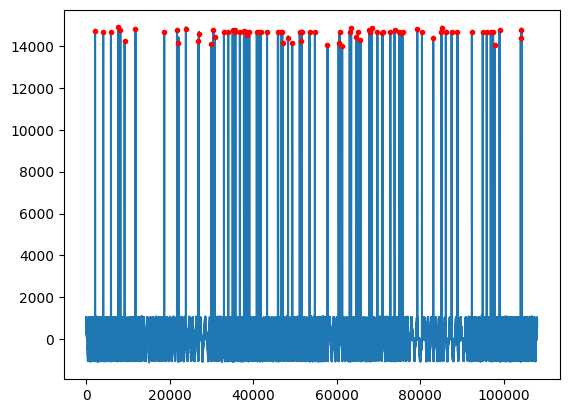

In [61]:
plt.figure()
plt.plot(data_ws[dates[0]]['rewards'])
plt.plot(reward_times[dates[0]], data_ws[dates[0]]['rewards'][reward_times[dates[0]]], '.r')

In [62]:
def make_loggerDF(logger, expParam):
    return {t: pd.DataFrame(logger[t], columns=expParam['loggerNames'][t]) for t in expParam['loggerNames'].keys()}

In [63]:
logger_dfs = {d: make_loggerDF(loggers[d], expParams[d]) for d in loggers.keys()}

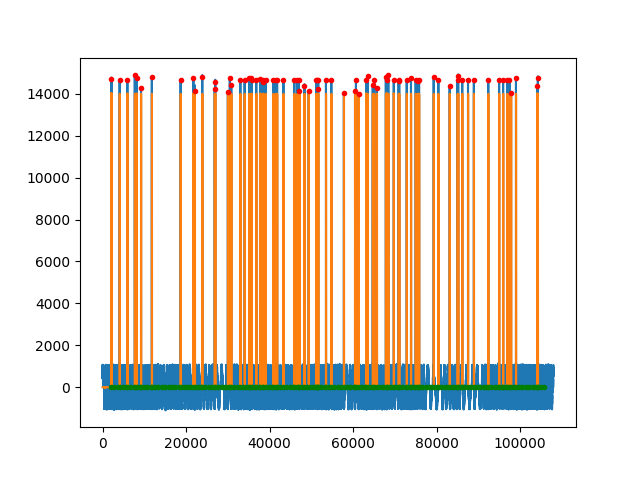

In [64]:
%matplotlib widget

plt.figure()
plt.plot(data_ws[dates[0]]['rewards'])
plt.plot(logger_dfs[dates[0]]['timeSeries']['CE_rewardDelivery'].to_numpy() * 14000)
plt.plot(reward_times[dates[0]], data_ws[dates[0]]['rewards'][reward_times[dates[0]]], '.r')
plt.plot(logger_dfs[dates[0]]['trials']['frameNum_trialEnd'], np.ones_like(logger_dfs[dates[0]]['trials']['frameNum_trialEnd']), '.g')

In [65]:
%matplotlib inline

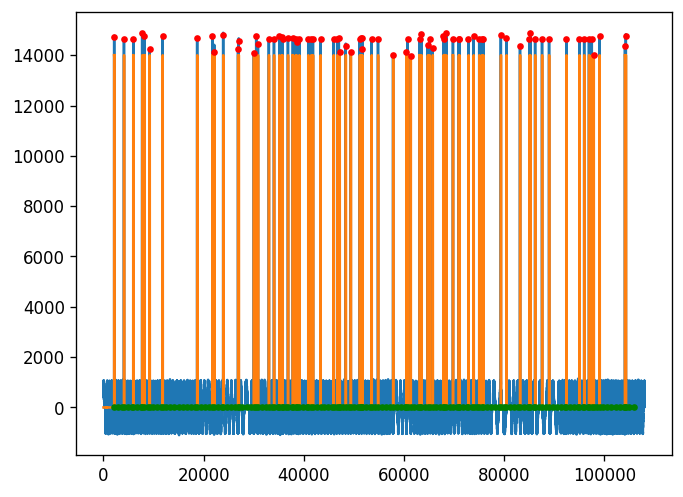

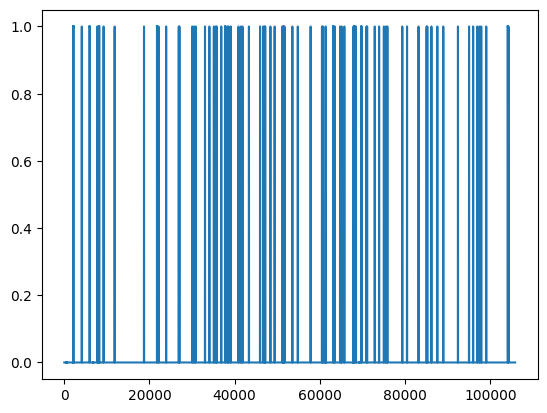

In [66]:
plt.figure()
plt.plot(logger_dfs[dates[0]]['timeSeries']['CE_rewardDelivery'])

In [67]:
def make_rewardTimesTyped(
    logger_df,
    reward_times, 
    thresh_diff=30, 
    offset_frames=2, 
    names_trial_types=['trialType_cursorOn', 'trialType_feedbackLinked', 'trialType_rewardOn', 'success_outcome'],
):
    bits_list = np.stack([np.unpackbits(np.array(ii, dtype=np.uint8))[-4:] for ii in range(16)], axis=0)
    bits_exp = np.stack([logger_df['trials'][name] for name in names_trial_types], axis=1)
    trialTypes = {tuple(bits.tolist()): np.where(np.packbits(bits_exp.astype(np.uint8), axis=1) == np.packbits(bits.astype(np.uint8)))[0] for bits in bits_list}

    end_frames = logger_df['trials']['frameNum_trialEnd'].to_numpy() - 1
    diffs = np.abs(reward_times[None, :] - end_frames[:, None])  ## note the -1 because the logger is 1-indexed from matlab
    
    idx_rt_matched = np.argmin(diffs, axis=1).astype(np.float32)  ## idx_logger__val_ws
    idx_rt_matched[np.all(np.isnan(diffs), axis=1)] = np.nan
    idx_rt_matched[np.nanmin(diffs, axis=1) > thresh_diff] = np.nan

    reward_times_loggerAligned = bnpm.indexing.index_with_nans(reward_times.astype(np.float32), idx_rt_matched)
    reward_times_loggerAligned[np.isnan(reward_times_loggerAligned)] = (logger_df['trials']['frameNum_trialEnd'][np.isnan(reward_times_loggerAligned)] - 1) + offset_frames

    ## If trial type is XX0X (reward off) or XXX0 (not success), then get the end frame from the trial
    reward_times_typed = {}
    for t, idx in trialTypes.items():
        if np.array(t)[3]==1 and np.array(t)[2]==1:
            reward_times_typed[t] = reward_times_loggerAligned[idx]
        else:
            reward_times_typed[t] = end_frames[idx]
#     reward_times_typed = {t: reward_times_loggerAligned[idx] for t, idx in trialTypes.items() if (np.array(t)[3]==1 and np.array(t)[2]==1) else endframes[idx]}

    return reward_times_typed

In [68]:
names_trial_types = ['trialType_cursorOn', 'trialType_feedbackLinked', 'trialType_rewardOn', 'success_outcome']

reward_times_typed = {d: make_rewardTimesTyped(logger_dfs[d], reward_times[d], thresh_diff=30, offset_frames=2, names_trial_types=names_trial_types) for d in reward_times.keys()}

/tmp/ipykernel_1675390/811597560.py:10: RuntimeWarning: invalid value encountered in cast
  trialTypes = {tuple(bits.tolist()): np.where(np.packbits(bits_exp.astype(np.uint8), axis=1) == np.packbits(bits.astype(np.uint8)))[0] for bits in bits_list}
/tmp/ipykernel_1675390/811597560.py:17: RuntimeWarning: All-NaN slice encountered
  idx_rt_matched[np.nanmin(diffs, axis=1) > thresh_diff] = np.nan


In [69]:
# val_idxSI__idx_SI4x = {date: np.linspace(start=0, stop=logger['timeSeries'].shape[0] - 1, num=int(logger['timeSeries'].shape[0] * 4), endpoint=True) for date, logger in logger_dfs.items()}

In [70]:
# idxSI4x_rewardTimesTyped =  {date: {t: bnpm.indexing.find_nearest_array(val_idxSI__idx_SI4x[date], rttt_t)[0] for t, rttt_t in rttt.items()} for date, rttt in reward_times_typed.items()}

In [71]:
# plt.figure()
# plt.imshow(np.abs(reward_times[dates[0]][None, :] - logger_dfs[dates[0]]['trials']['frameNum_trialEnd'].to_numpy()[:, None] - 1), aspect='auto')
# # plt.show()

In [72]:
## check to make sure the signal is correct

In [73]:
import bnpm.similarity


neural_decoderProj = bnpm.similarity.proj(
    v1=data_neural_aligned[date_day0],
    v2=weights_day0_idxFactors,
    nan_handling='ignore',
)[1]

(20000.0, 38000.0)

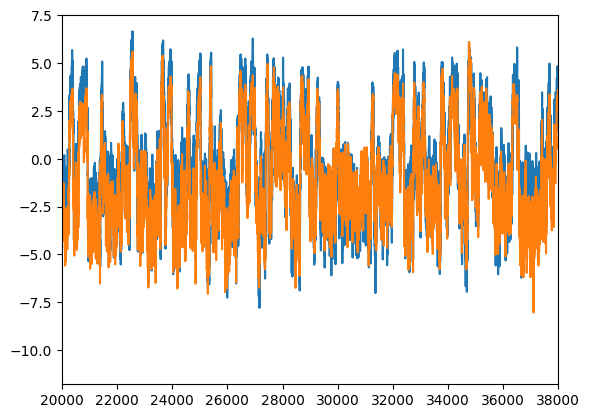

In [108]:
idx_factor = 0

plt.figure()
plt.plot(decoderDefinition['results']['simulation']['M'][0].cpu().numpy())
# plt.plot(test[1][:, 0]/100)
plt.plot(scipy.signal.savgol_filter(neural_decoderProj[:, idx_factor], window_length=5, polyorder=1)/6 + 2)
# plt.plot(scipy.signal.savgol_filter(neural_decoderProj[(decoderDefinition['results']['idx_time_bad'][-1][-1]+1):, idx_factor], window_length=5, polyorder=1)/120 + 2)
plt.xlim(20000, 38000)

In [91]:
names_trial_types

['trialType_cursorOn',
 'trialType_feedbackLinked',
 'trialType_rewardOn',
 'success_outcome']

In [92]:
reward_times_typed[dates[-1]][(1, 1, 1, 1)].shape, data_neural_aligned[dates[-1]].shape

((185,), (589, 108000))

In [93]:
import bnpm.torch_helpers


def preprocess_neural_data(data):
    ## z-score the data
    out = torch.as_tensor(data, dtype=torch.float32)
    out = (out - torch.nanmean(out, dim=-1, keepdims=True)) / bnpm.torch_helpers.nanstd(out, dim=-1, keepdims=True)
    return out

In [94]:
data_neural_preprocessed = {date: preprocess_neural_data(d) for date, d in tqdm(data_neural_aligned.items())}

  0%|          | 0/6 [00:00<?, ?it/s]

In [95]:
Fs = 30  # Hz
win_bounds = [-Fs*2, Fs*2]

In [96]:
et_neural = {date: bnpm.timeSeries.event_triggered_traces(
    arr=data_neural_aligned[date],
    idx_triggers=reward_times_typed[date][(1,1,1,1)][:].astype(np.int64),
#     win_bounds=[-4*30*5, 4*30*5],
    win_bounds=win_bounds,
    dim=-1,
    verbose=False,
)[0] for date in tqdm(dates)}

  0%|          | 0/6 [00:00<?, ?it/s]

/media/rich/Home_Linux_partition/github_repos/basic_neural_processing_modules/bnpm/timeSeries.py:412: UserWarning: idx_triggers are likely in boolean format. Please convert to index format via np.where or torch.where or similar
  warn("idx_triggers are likely in boolean format. Please convert to index format via np.where or torch.where or similar")


In [97]:
et_neural[dates[-1]].shape

(589, 185, 120)

In [98]:
data_neural_aligned[dates[-1]].shape

(589, 108000)

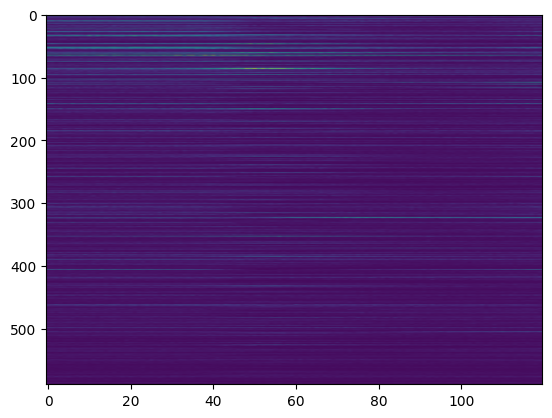

In [99]:
plt.figure()
plt.imshow(et_neural[dates[-1]].mean(1), aspect='auto', clim=(-1, 50))

In [100]:
names_trial_types

['trialType_cursorOn',
 'trialType_feedbackLinked',
 'trialType_rewardOn',
 'success_outcome']

In [101]:
import bnpm.timeSeries

trial_type = (1, 1, 1, 1)  # cursorOn, feedbackLinked, rewardOn, success_outcome

et_neural = {date: bnpm.timeSeries.make_sorted_event_triggered_average(
    arr=data_neural_aligned[date],
    idx_triggers=reward_times_typed[date][trial_type][:].astype(np.int64),
#     win_bounds=[-4*30*5, 4*30*5],
    win_bounds=win_bounds,
    dim=-1,
    cv_group_size=1,
    test_frac=0.5,
    show_plot=False,
)[0] for date in tqdm(dates) if reward_times_typed[date][trial_type].size > 1}

  0%|          | 0/6 [00:00<?, ?it/s]

In [102]:
dates_to_plot = list(et_neural.keys())[-10:]

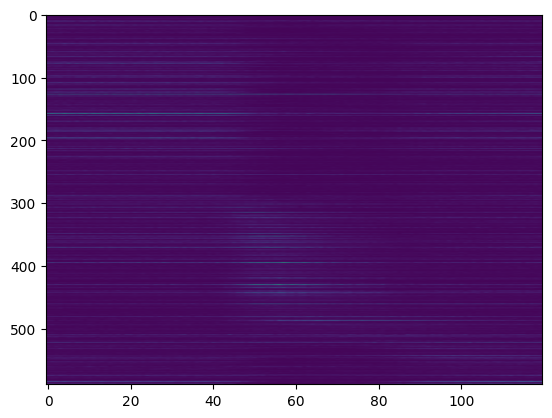

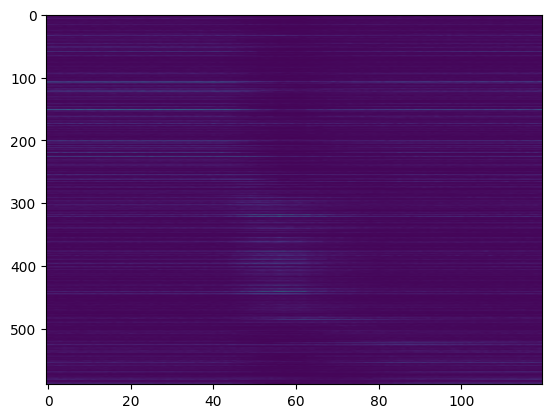

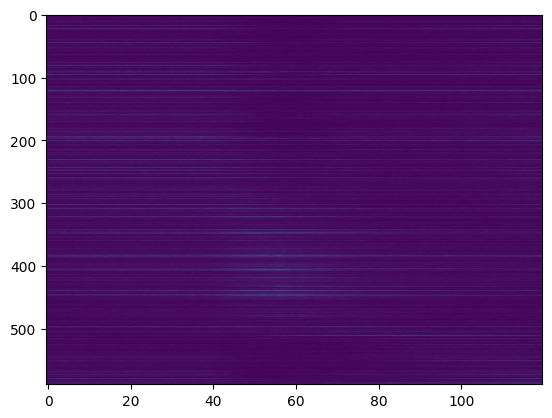

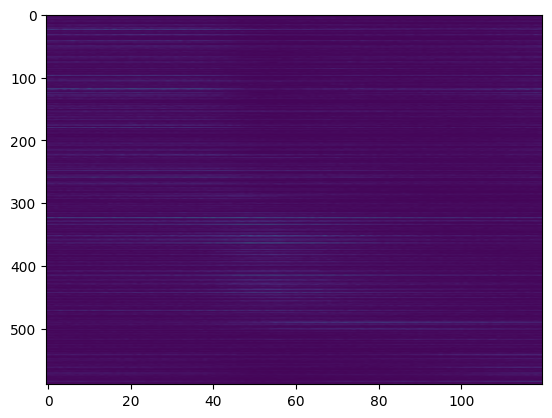

In [104]:
for date in dates_to_plot:
    if et_neural[date] is not None:
        plt.figure()
        plt.imshow(et_neural[date], aspect='auto', clim=(-1, 100))

In [109]:
data_neural_aligned[date].shape, weights_day0_idxFactors.shape

((589, 108000), (589, 3))

In [110]:
%load_ext autoreload
%autoreload 2
import richfile as rf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [111]:
r = rf.demo.RichFile_data(path=f'/media/rich/bigSSD/analysis_data/BMI/gershman_packets/{mouse}')

In [112]:
r.save(obj={
    'data_neural_aligned': data_neural_aligned,
    'weights_day0_idxFactors': weights_day0_idxFactors,
    'lick_times': lick_times,
    'reward_times_typed': reward_times_typed,
    'data_ws': data_ws,
    'date_day0': date_day0,
    'extras': {
        'paths': {
            'paths_neural': paths_neural,
            'paths_tqm': paths_tqm,
            'paths_ws': paths_ws,
            'paths_loggers': paths_loggers,
            'paths_expParams': paths_expParams,
            'paths_roicatClassification': path_roicatClassification,
            'paths_roicatTracking': path_roicatTracking,
        },
        'tracking': {
            'iscell_roicatClassification': iscell_roicatClassification,
            'labels_bySession': labels_bySession,
            'sampleSilhouette_bySession': sampleSilhouette_bySession,
            'weights_day0_idxDay0': weights_day0_idxDay0,
            'weights_day0': weights_day0,
            'iscell_tqm': iscells_tqm,
            'iscell_roicatClassification': iscell_roicatClassification,
            'idx_inverse_ucids': idx_inverse_ucids,
            'labels_bySession_modified': labels_bySession_modified,
        },
        'dates': dates,
        'reward_times': reward_times,
        'logger_dfs': logger_dfs,
        'expParams': expParams,
    },
},)

Path: /media/rich/bigSSD/analysis_data/BMI/gershman_packets/mouse_0403R (dict)
├── 'data_neural_aligned':   (dict)
|    ├── '20230702':   (numpy_array)
|    ├── '20230703':   (numpy_array)
|    ├── '20230706':   (numpy_array)
|    ├── '20230707':   (numpy_array)
|    ├── '20230708':   (numpy_array)
|    ├── '20230709':   (numpy_array)
|    
├── 'weights_day0_idxFactors':   (numpy_array)
├── 'lick_times':   (dict)
|    ├── '20230702':   (numpy_array)
|    ├── '20230703':   (numpy_array)
|    ├── '20230706':   (numpy_array)
|    ├── '20230707':   (numpy_array)
|    ├── '20230708':   (numpy_array)
|    ├── '20230709':   (numpy_array)
|    
├── 'reward_times_typed':   (dict)
|    ├── '20230702':   (dict)
|    |    ├── '(0, 0, 0, 0)':   (numpy_array)
|    |    ├── '(0, 0, 0, 1)':   (numpy_array)
|    |    ├── '(0, 0, 1, 0)':   (numpy_array)
|    |    ├── '(0, 0, 1, 1)':   (numpy_array)
|    |    ├── '(0, 1, 0, 0)':   (numpy_array)
|    |    ├── '(0, 1, 0, 1)':   (numpy_array)
|    |    ├── 

RichFile(path=/media/rich/bigSSD/analysis_data/BMI/gershman_packets/mouse_0403R, check=True, params_load={}, params_save={})